In [90]:
from matplotlib import pyplot as plt
import seaborn as sns

import numpy as np

from PIL import Image
from skimage.color import rgb2lab

from sklearn.cluster import MeanShift, KMeans

from scipy.ndimage import median_filter

path = "imgs/frame.jpeg"

In [91]:
# Crop to important part
img = np.array(Image.open(path))[558:-250]
H, W, _ = img.shape

# Make colors more consistent
kmeans = KMeans(n_clusters=8, random_state=0).fit(img.reshape(-1, 3))
quantized = kmeans.cluster_centers_[kmeans.labels_].astype(np.uint8)
img = quantized.reshape(img.shape)

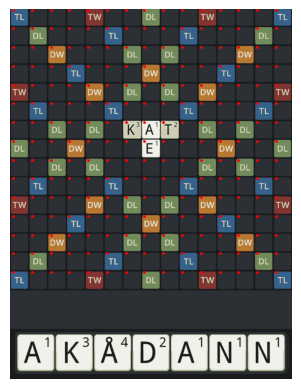

In [92]:
# Constants
board_offset  = 10
tile_size     = W//15

# Define meshgrid
x = np.arange(15)*tile_size
y = np.arange(15)*tile_size
X, Y = np.meshgrid(x, y)
X += board_offset
points = np.column_stack([Y.ravel(), X.ravel()])

# Extract colors at tiles
rows, cols = zip(*points)
values = img[rows, cols, :].reshape(15,15,3)

# Plot board
plt.imshow(img, cmap='Accent')
plt.scatter(X, Y, c='r', s=1)
plt.axis('off')
plt.show()

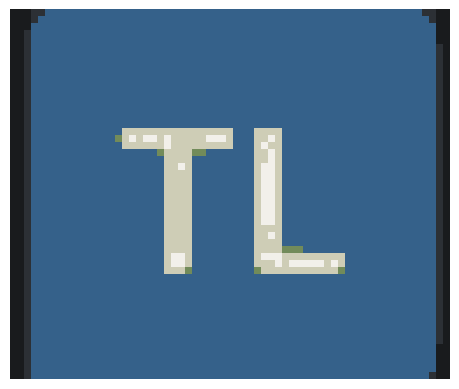

In [ ]:
# Get any tile
xi, yi = 13,5
tile = img[x[xi]:x[xi]+tile_size-board_offset, y[yi]:y[yi]+tile_size]
plt.imshow(tile)
plt.axis('off')
plt.show()

# Get any letter

In [93]:
# Convert pixels to color labels
colormap = {
    (41,44,49)    : 0, # board background
    (234,233,222) : 1, # letter background
    (117,141,95)  : 2, # DL
    (53,97,138)   : 3, # TL
    (184,121,51)  : 4, # DW
    (130,52,49)   : 5, # TW
}

# Map values to closest color in colormap
def closest_color(rgb):
    min_dist = float('inf')
    closest = None
    for color in colormap.keys():
        dist = np.linalg.norm(np.array(rgb) - np.array(color))
        if dist < min_dist:
            min_dist = dist
            closest = color
    return colormap[closest]

mapped = np.zeros((15,15), dtype=object)
for i in range(15):
    for j in range(15):
        mapped[i,j] = closest_color(values[i,j])
        
mapped

array([[3, 0, 0, 0, 5, 0, 0, 2, 0, 0, 5, 0, 0, 0, 3],
       [0, 2, 0, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 2, 0],
       [0, 0, 4, 0, 0, 0, 2, 0, 2, 0, 0, 0, 4, 0, 0],
       [0, 0, 0, 3, 0, 0, 0, 4, 0, 0, 0, 3, 0, 0, 0],
       [5, 0, 0, 0, 4, 0, 2, 0, 2, 0, 4, 0, 0, 0, 5],
       [0, 3, 0, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 3, 0],
       [0, 0, 2, 0, 2, 0, 1, 1, 1, 0, 2, 0, 2, 0, 0],
       [2, 0, 0, 4, 0, 0, 0, 1, 0, 0, 0, 4, 0, 0, 2],
       [0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0],
       [0, 3, 0, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 3, 0],
       [5, 0, 0, 0, 4, 0, 2, 0, 2, 0, 4, 0, 0, 0, 5],
       [0, 0, 0, 3, 0, 0, 0, 4, 0, 0, 0, 3, 0, 0, 0],
       [0, 0, 4, 0, 0, 0, 2, 0, 2, 0, 0, 0, 4, 0, 0],
       [0, 2, 0, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 2, 0],
       [3, 0, 0, 0, 5, 0, 0, 2, 0, 0, 5, 0, 0, 0, 3]], dtype=object)

In [94]:
letter_data = {
    "A": {"antal": 7, "point": 1},
    "B": {"antal": 4, "point": 3},
    "C": {"antal": 2, "point": 8},
    "D": {"antal": 5, "point": 2},
    "E": {"antal": 9, "point": 1},
    "F": {"antal": 3, "point": 3},
    "G": {"antal": 3, "point": 3},
    "H": {"antal": 2, "point": 4},
    "I": {"antal": 4, "point": 3},
    "J": {"antal": 2, "point": 4},
    "K": {"antal": 4, "point": 3},
    "L": {"antal": 5, "point": 2},
    "M": {"antal": 3, "point": 4},
    "N": {"antal": 7, "point": 1},
    "O": {"antal": 5, "point": 2},
    "P": {"antal": 2, "point": 4},
    "R": {"antal": 7, "point": 1},
    "S": {"antal": 6, "point": 2},
    "T": {"antal": 6, "point": 2},
    "U": {"antal": 3, "point": 3},
    "V": {"antal": 3, "point": 4},
    "X": {"antal": 1, "point": 8},
    "Y": {"antal": 2, "point": 4},
    "Z": {"antal": 1, "point": 9},
    "Æ": {"antal": 2, "point": 4},
    "Ø": {"antal": 2, "point": 4},
    "Å": {"antal": 2, "point": 4},
}

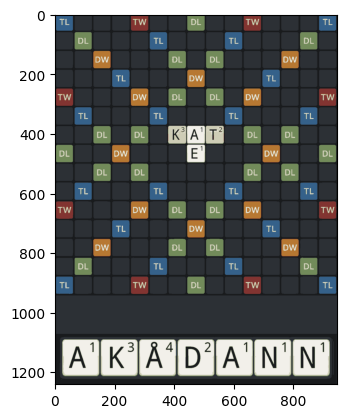

In [97]:
plt.imshow(img);

In [117]:
import easyocr
import cv2

reader = easyocr.Reader(['da'])  # Danish, loads once

results = reader.readtext(tile, allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZÆØÅ123456789')
for (bbox, text, confidence) in results:
    print(f"{text} ({confidence:.2f})")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


TL (1.00)


/home/mp/Desktop/WordfuedRL/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
